In [1]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor
import cv2
import gc
import os
from tensorflow.random import set_seed
from sklearn.utils import shuffle
from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam

2026-05-20 18:14:34.267591: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779300874.291455    4556 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779300874.299128    4556 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779300874.319348    4556 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779300874.319368    4556 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779300874.319371    4556 computation_placer.cc:177] computation placer alr

In [2]:
os.environ['PYTHONHASHSEED'] = '0'
os.environ['TF_DETERMINISTIC_OPS'] = '1'

random.seed(42)
np.random.seed(42)
set_seed(42)

In [3]:
TRAIN_PATH = '/kaggle/input/datasets/rightway11/state-farm-distracted-driver-detection/imgs/train/'
IMG_SIZE = (192, 192)

def load_cv2(p):
    img = cv2.imread(p)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return cv2.resize(img, (IMG_SIZE[1], IMG_SIZE[0]))
    
def load_images(df):
    img_path = (TRAIN_PATH + '/' + df['classname'] + '/' + df['img'])
    with ThreadPoolExecutor() as executor:
        data = list(executor.map(load_cv2, img_path))
    data_array = np.array(data, dtype='float16') 
    return preprocess_input(data_array)

In [4]:
df = pd.read_csv('/kaggle/input/datasets/rightway11/state-farm-distracted-driver-detection/driver_imgs_list.csv')

In [5]:
Val_Drivers = ['p012','p075','p021','p024','p035','p064']

In [6]:
safe = df.query(f"classname == 'c0' and subject not in {Val_Drivers}").copy()
texting = df.query(f"classname in ['c1', 'c3'] and subject not in {Val_Drivers}").copy()
calling = df.query(f"classname in ['c2', 'c4'] and subject not in {Val_Drivers}").copy()

valid = df.query(f"subject in {Val_Drivers} and classname in ['c0','c1', 'c3','c2', 'c4']")

In [7]:
x_safe = load_images(safe)
x_text = load_images(texting)
x_call = load_images(calling)
x_valid = load_images(valid)

x_train = np.concatenate((x_safe, x_text,x_call), axis = 0)
maps = {
        'c0':0,
        'c1':1,
        'c3':1,
        'c2':2,
        'c4':2,
}

y_safe = np.zeros(x_safe.shape[0])
y_text = np.ones(x_text.shape[0])
y_call = np.full(x_call.shape[0], 2)
y_valid = valid['classname'].map(maps)

y_train = np.concatenate((y_safe, y_text, y_call),axis = 0)

x_train, y_train = shuffle(x_train, y_train, random_state=42) #To randomize.

In [8]:
base_model = MobileNetV2(
    input_shape = (*IMG_SIZE,3),
    include_top = False,
    weights = 'imagenet'
)

I0000 00:00:1779300944.310187    4556 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [9]:
base_model.trainable = False
fine_tune_at = 30
penalty = 0.00001

for layer in base_model.layers[-fine_tune_at:]:
    layer.trainable = True

regularizer = l2(penalty)
for layer in base_model.layers:
    for attr in ['kernel_regularizer']:
        if hasattr(layer, attr):
          setattr(layer, attr, regularizer)
            
model = models.Sequential([
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),       
    layers.RandomTranslation(0.1, 0.1),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    
    layers.Dropout(0.4),
    layers.Dense(64, activation='relu'),
    
    layers.Dense(10, activation='softmax')
])
model.compile(Adam(learning_rate = 0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [10]:
checkpoint_callback = ModelCheckpoint(
    filepath='best_mobilenet_v2.keras',  # File path where model will be saved
    monitor='val_loss',               # Metric to watch (Validation Loss)
    save_best_only=True,              # Keeps only the best epoch, overwrites worse ones
    mode='min'                        # 'min' because lower loss is better
)

In [11]:
results = model.fit(
    x_train,y_train,
    validation_data = (x_valid,y_valid),
    batch_size = 32,
    epochs = 30,
    callbacks=[checkpoint_callback]
)

Epoch 1/30


2026-05-20 18:16:06.614305: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
I0000 00:00:1779300977.088714    4651 cuda_dnn.cc:529] Loaded cuDNN version 91002


381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7996 - loss: 0.4915

2026-05-20 18:16:48.473373: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


381/381 ━━━━━━━━━━━━━━━━━━━━ 54s 97ms/step - accuracy: 0.7999 - loss: 0.4908 - val_accuracy: 0.4736 - val_loss: 10.9527
Epoch 2/30
381/381 ━━━━━━━━━━━━━━━━━━━━ 24s 63ms/step - accuracy: 0.9755 - loss: 0.0828 - val_accuracy: 0.8501 - val_loss: 1.7800
Epoch 3/30
381/381 ━━━━━━━━━━━━━━━━━━━━ 23s 62ms/step - accuracy: 0.9898 - loss: 0.0370 - val_accuracy: 0.7216 - val_loss: 6.2628
Epoch 4/30
381/381 ━━━━━━━━━━━━━━━━━━━━ 25s 64ms/step - accuracy: 0.9893 - loss: 0.0441 - val_accuracy: 0.8989 - val_loss: 1.1906
Epoch 5/30
381/381 ━━━━━━━━━━━━━━━━━━━━ 23s 61ms/step - accuracy: 0.9897 - loss: 0.0373 - val_accuracy: 0.8570 - val_loss: 1.4330
Epoch 6/30
381/381 ━━━━━━━━━━━━━━━━━━━━ 25s 67ms/step - accuracy: 0.9925 - loss: 0.0340 - val_accuracy: 0.9333 - val_loss: 0.7129
Epoch 7/30
381/381 ━━━━━━━━━━━━━━━━━━━━ 24s 62ms/step - accuracy: 0.9926 - loss: 0.0318 - val_accuracy: 0.8712 - val_loss: 2.1007
Epoch 8/30
381/381 ━━━━━━━━━━━━━━━━━━━━ 25s 65ms/step - accuracy: 0.9929 - loss: 0.0305 - val_accura

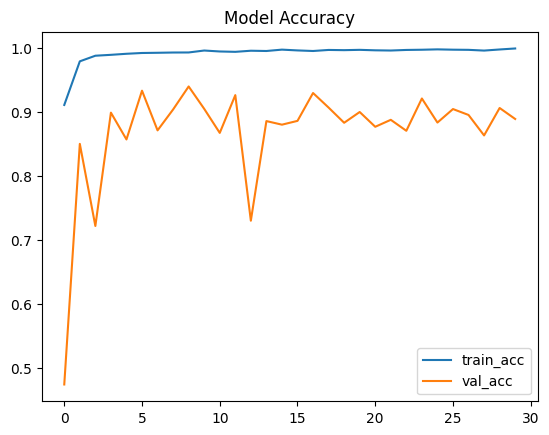

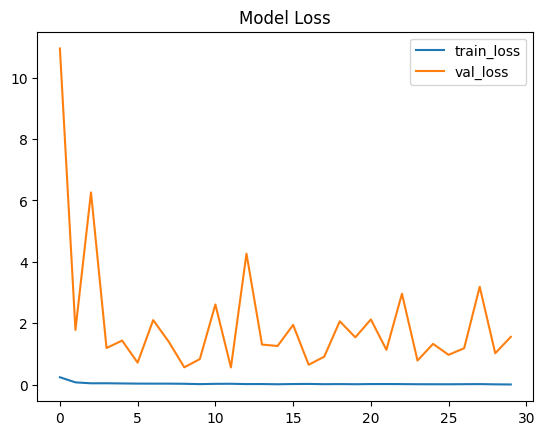

In [12]:
# Accuracy Plot
plt.plot(results.history['accuracy'], label='train_acc')
plt.plot(results.history['val_accuracy'], label='val_acc')
plt.title('Model Accuracy')
plt.legend()
plt.show()

# Loss Plot
plt.plot(results.history['loss'], label='train_loss')
plt.plot(results.history['val_loss'], label='val_loss')
plt.title('Model Loss')
plt.legend()
plt.show()

[*] Scanning folder: /kaggle/input/datasets/mohamedtarek223/moaaz-testing


2026-05-20 18:28:33.298627: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


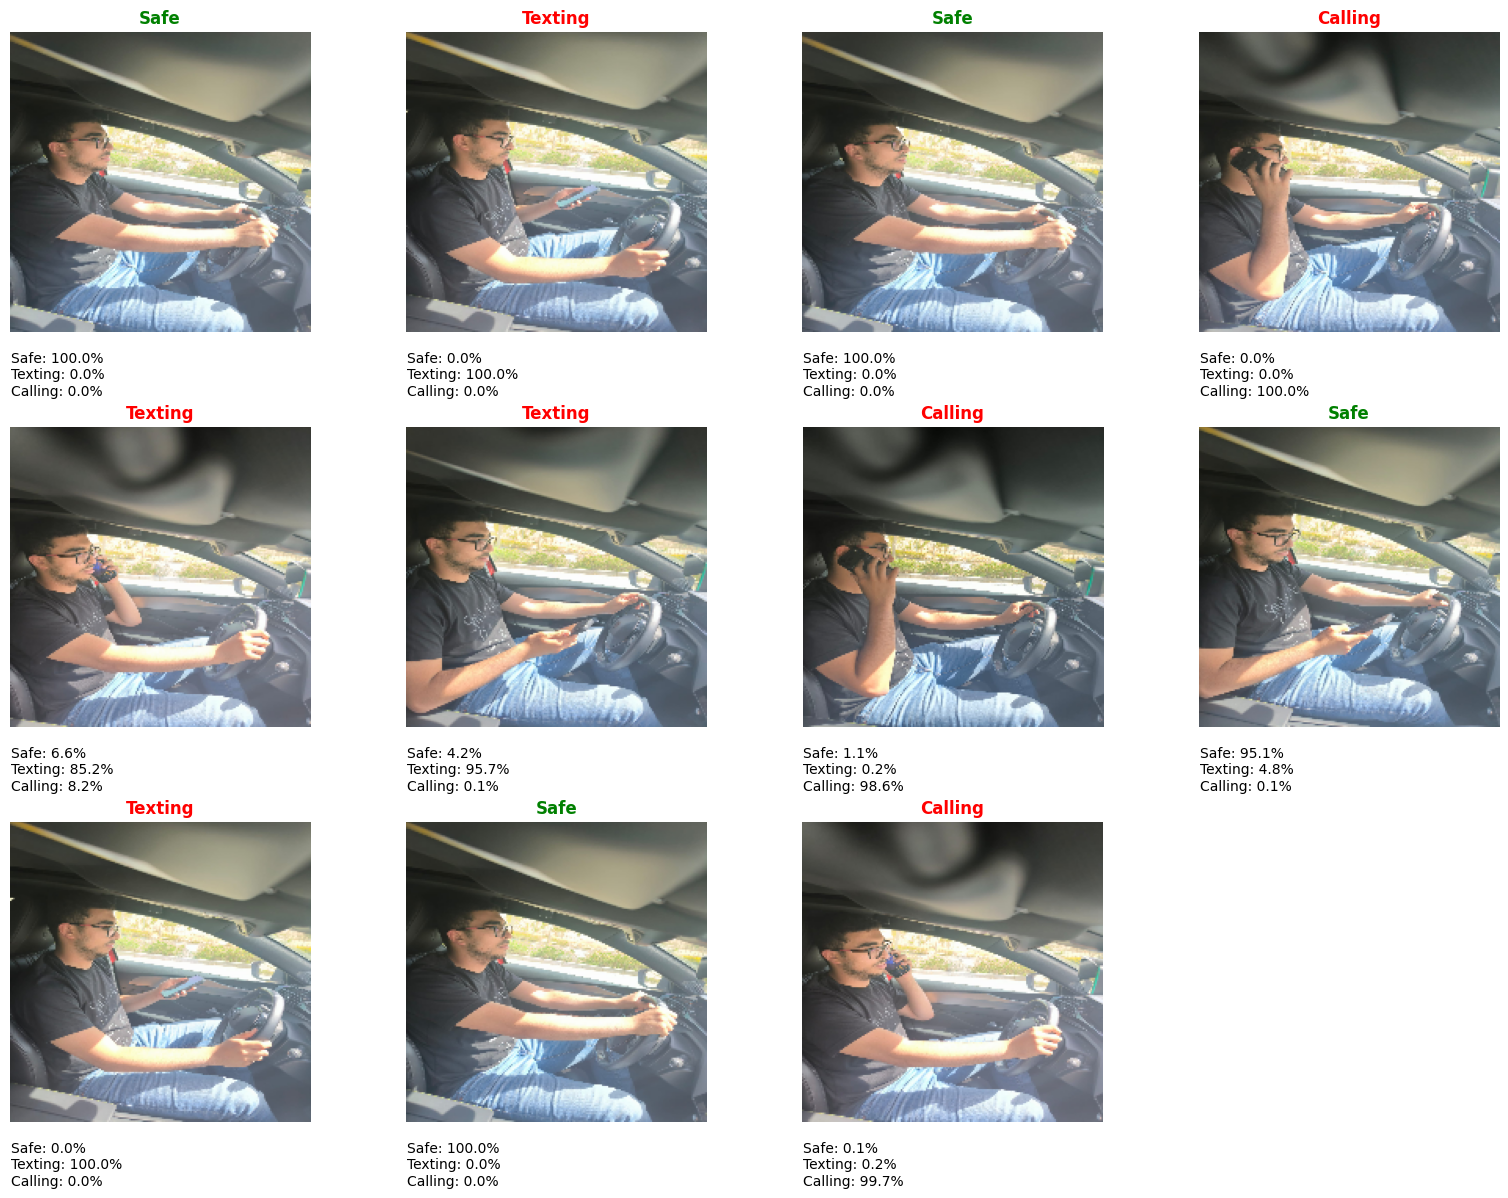

In [13]:
IMG_SIZE = (192, 192) 
class_labels = ['Safe', 'Texting', 'Calling']
IMAGE_FOLDER = '/kaggle/input/datasets/mohamedtarek223/moaaz-testing'

fig = plt.figure(figsize=(16, 12))
count = 1

print(f"[*] Scanning folder: {IMAGE_FOLDER}")

for filename in os.listdir(IMAGE_FOLDER):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        img_path = os.path.join(IMAGE_FOLDER, filename)
        
        original_img = cv2.imread(img_path)
        if original_img is None: 
            continue
        img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
        
        resized_img = cv2.resize(img_rgb, (IMG_SIZE[1], IMG_SIZE[0]))
        
        input_array = np.expand_dims(resized_img, axis=0).astype('float32')
        
        input_array = preprocess_input(input_array)
        
        preds = model.predict(input_array, verbose=0)[0]
        
        idx = np.argmax(preds)
        winner_conf = preds[idx] * 100
        winner_label = class_labels[idx]
        
        stats_text = (f"Safe: {preds[0]*100:.1f}%\n"
                      f"Texting: {preds[1]*100:.1f}%\n"
                      f"Calling: {preds[2]*100:.1f}%")
        
        plt.subplot(3, 4, count) 
        plt.imshow(resized_img)
        
        text_color = 'green' if winner_label == 'Safe' else 'red'
        plt.title(f"{winner_label}", color=text_color, fontweight='bold', fontsize=12)
        plt.text(0, IMG_SIZE[1] + 40, stats_text, fontsize=10, 
                 bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        plt.axis('off')
        
        count += 1
        if count > 12: 
            break

plt.tight_layout()
plt.show()